# Imbalance Dataset


In [1]:
# import required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("decision_tree_dataset.csv")

In [3]:
df.head()

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        1050 non-null   float64
 2   credit_score  1050 non-null   float64
 3   gender        1050 non-null   int64  
 4   purchases     1050 non-null   int64  
 5   loan_amount   1050 non-null   float64
 6   approved      1050 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 57.6 KB


In [20]:
df.isnull().sum()

age             0
income          0
credit_score    0
gender          0
purchases       0
loan_amount     0
approved        0
dtype: int64

In [5]:
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


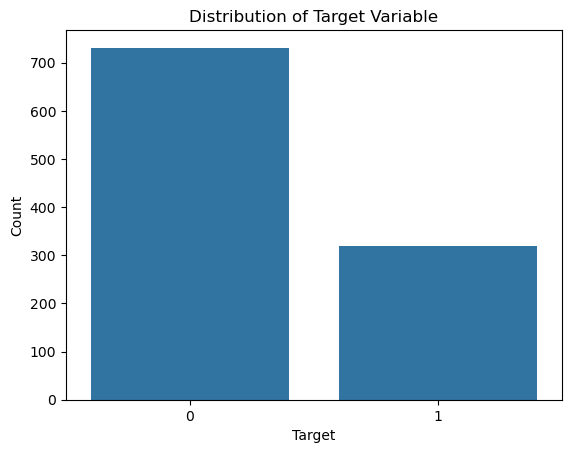

In [21]:
# step 4: Data Visualisation
sns.countplot(x='approved', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

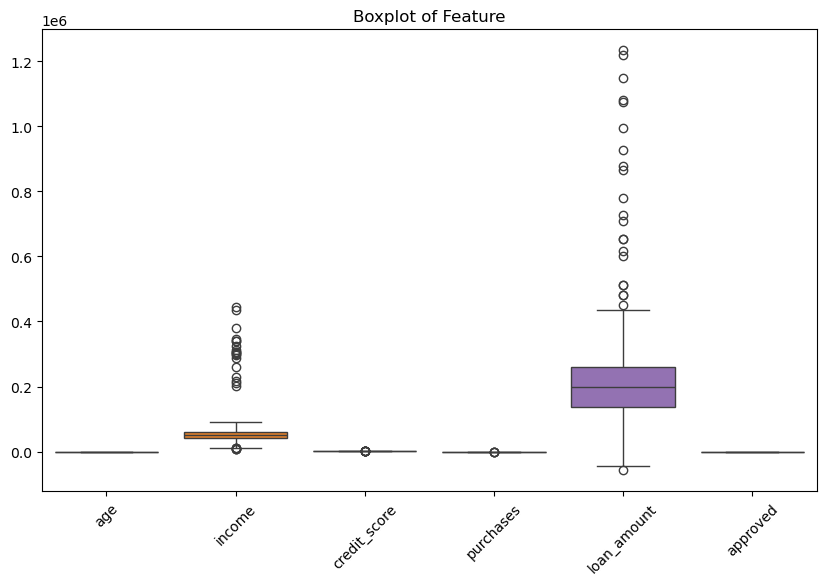

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot of Feature')
plt.xticks(rotation=45)
plt.show()

In [7]:
# Handdle the missing value fill the missing value 

# fild the all columns which have missingvalues

income_median = round(df['income'].median(),2)
credit_score_median = round(df['credit_score'].median(),2)
loan_amount_mean = round(df['loan_amount'].mean(),2)

# fill the missing values with median and mean values
df['income'].fillna(income_median, inplace=True)
df['credit_score'].fillna(credit_score_median, inplace=True)
df['loan_amount'].fillna(loan_amount_mean, inplace=True)

C:\Users\SANDY\AppData\Local\Temp\ipykernel_1220\3883255955.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(income_median, inplace=True)
C:\Users\SANDY\AppData\Local\Temp\ipykernel_1220\3883255955.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

<Axes: ylabel='credit_score'>

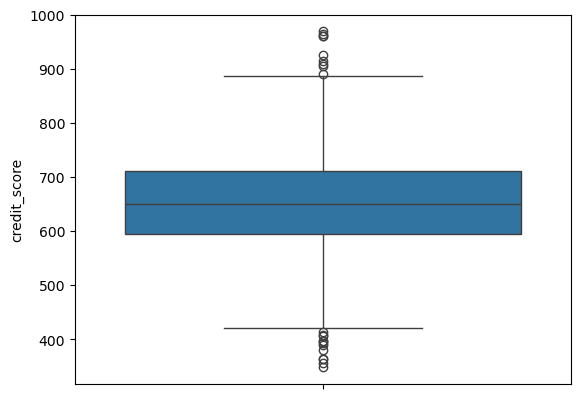

In [22]:
sns.boxplot(data=df['credit_score'])

In [23]:
# handel the outlier using IqR method


outlier_columns =['income' , 'credit_score' , 'loan_amount']

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# handele the outlier clipping the outlier values to the lower and upper 
df[col] = df[col].clip(lower = lower_bound,upper =upper_bound)

In [27]:
# drop the citty colum 
df.drop('city', axis=1 inplace=True)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1460758421.py, line 2)

In [28]:
# reolace the gender col 0 and 1
df['gender'] = df['gender'].replace({'Male':0 ,'Female':1})


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        1050 non-null   float64
 2   credit_score  1050 non-null   float64
 3   gender        1050 non-null   int64  
 4   purchases     1050 non-null   int64  
 5   loan_amount   1050 non-null   float64
 6   approved      1050 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 57.6 KB


In [16]:
# split the datset into features and terget variab;le
X = df.drop('approved',axis=1)
y = df['approved']


In [29]:
y.value_counts()

approved
0    731
1    319
Name: count, dtype: int64

In [ ]:
 #handle the imbalanced dataset using random oversmpler technique

from imblearn.over_sampling import RandomOverSampler

# instance of RandomOversample(random_state=42)
ros = RandomOverSampler(random_state=42)

# fit and trensform the traing data
X_resampled , y_resampled = ros.fit_resample(X,y)


In [31]:
# 2: SMOTE technique
from imblearn.over_sampling import SMOTE

# instance of SMOTE

smote = SMOTE(random_state=42)

# fit and transform the training data
X_resampled, y_resampled = smote.fit_resample(X, y)



In [34]:
y_resampled.value_counts()

approved
0    731
1    731
Name: count, dtype: int64

In [35]:
# split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size =0.20,
    random_state=42

)

In [33]:
X_test.head(5)

,age,income,credit_score,gender,purchases,loan_amount
892,26,50967.120000,716.874166,1,3,110338.587944
1106,55,58611.544511,810.400301,0,3,208606.620000
413,33,323701.823796,543.219708,1,2,95026.943904
522,28,49770.352262,547.062849,1,3,358690.692195
1036,28,50276.508996,596.403655,1,2,229882.694673


In [36]:
# step 7: model building 
from sklearn.linear_model import LogisticRegression

# instance of Logistic reg
LR = LogisticRegression()

# train the model on x_train y_train
model = LR.fit(X_train,y_train)

#x_test
y_pred = model.predict(X_test)

c:\Users\SANDY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
# step 8: model evalution

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# find the accurasy 
accuracy = accuracy_score(y_test,y_pred)

# find the confusion metrics
confusion = confusion_matrix(y_test,y_pred)

# find the classification report 
report = classification_report(y_test,y_pred)



In [39]:
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(confusion)
print("Classification Report:")
print(report)

Accuracy: 0.689419795221843
Confusion Matrix:
[[106  55]
 [ 36  96]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70       161
           1       0.64      0.73      0.68       132

    accuracy                           0.69       293
   macro avg       0.69      0.69      0.69       293
weighted avg       0.70      0.69      0.69       293

